In [1]:
import os
import glob
import json
import numpy as np
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import torchvision.models as models

In [2]:
DATASET_DIR = "/kaggle/input/datasets/qianlanzz/xbd-dataset/xbd/tier1" 
MODEL_PATH = "/kaggle/input/datasets/nicolashernandez1307/unetformer-localization-weights/unetformer_best_localization.pth"

In [3]:
# Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## XBD PRE-DISASTER DATASET LOADER

In [4]:
class xBDPreDisasterMaskDataset(Dataset):
    def __init__(self, base_dir, transform=None):
        self.base_dir = base_dir
        self.transform = transform
        
        images_dir = os.path.join(base_dir, "images")
        masks_dir = os.path.join(base_dir, "masks")
        
        # 1. Get all pre-disaster images
        all_pre_images = sorted(glob.glob(os.path.join(images_dir, "*_pre_disaster.png")))
        
        # 2. Pair each image with its matching binary mask file name
        valid_pairs = []
        for img_path in all_pre_images:
            filename = os.path.basename(img_path)
            mask_path = os.path.join(masks_dir, filename)
            
            # Fallback check: if masks aren't in a subfolder, check root base_dir/masks or base_dir
            if not os.path.exists(mask_path):
                mask_path = os.path.join(base_dir, filename)
                
            if os.path.exists(mask_path):
                valid_pairs.append((img_path, mask_path))
            else:
                
                pass
        
        self.valid_pairs = valid_pairs
        print(f"Found {len(self.valid_pairs)} matching image/mask pairs in Tier1.")

    def __len__(self):
        return len(self.valid_pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.valid_pairs[idx]
        
        # Read pre-disaster image (RGB)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Read binary mask (Grayscale)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # Convert non-zero mask pixels to 1.0 (binary float)
        mask = (mask > 0).astype(np.float32)
        
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
            
        return image, mask.unsqueeze(0), os.path.basename(img_path)

# Transformations matching your model's expected inputs
test_transform = A.Compose([
    A.Resize(512, 512), # Adjust or comment out if evaluating full 1024x1024 resolution
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

## EFFICIENT GLOBAL-LOCAL ATTENTION BLOCK

In [5]:
class EfficientGlobalLocalAttention(nn.Module):
    def __init__(self, channels):
        super(EfficientGlobalLocalAttention, self).__init__()
        self.channels = channels
        
        # Local Attention Branch (Uses Depthwise Separable Convolution)
        self.local_branch = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, groups=channels, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True)
        )
        
        # Global Attention Branch (Reduces spatial dimension to map long-range features)
        self.pool = nn.AdaptiveAvgPool2d(4)  # Reduces feature map to a 4x4 matrix
        self.fc_query = nn.Conv2d(channels, channels, kernel_size=1)
        self.fc_key   = nn.Conv2d(channels, channels, kernel_size=1)
        self.fc_value = nn.Conv2d(channels, channels, kernel_size=1)
        
        # Softmax to calculate attention probabilities
        self.softmax = nn.Softmax(dim=-1)
        
        # Final aggregation layer combining both branches
        self.proj = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        B, C, H, W = x.shape
        
        # 1. Process Local Branch
        local_feat = self.local_branch(x)
        
        # 2. Process Global Branch using spatial-reduction attention
        q = self.fc_query(x).flatten(2)        # Shape: (B, C, H*W)
        
        pooled_x = self.pool(x)
        k = self.fc_key(pooled_x).flatten(2)   # Shape: (B, C, 16)
        v = self.fc_value(pooled_x).flatten(2) # Shape: (B, C, 16)
        
        # Matrix multiplication to compute cross-attention
        energy = torch.bmm(q.transpose(1, 2), k) # Intersecting queries with compact keys
        attention = self.softmax(energy)
        
        # Apply attention map weights to global values
        global_feat = torch.bmm(v, attention.transpose(1, 2))
        global_feat = global_feat.view(B, C, H, W)
        
        # 3. Fuse features via element-wise addition and projection
        fused = local_feat + global_feat
        return self.proj(fused)

## UNETFORMER DECODER BLOCK

In [6]:
class UNetFormerDecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super(UNetFormerDecoderBlock, self).__init__()
        
        # Attention block processing the feature input
        self.attention = EfficientGlobalLocalAttention(in_channels)
        
        # Upsampling module to double spatial resolution
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        
        # Convolution blocks blending upsampled features with skip features
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip_features):
        x = self.attention(x)
        x = self.upsample(x)
        x = torch.cat([x, skip_features], dim=1)
        return self.conv(x)

## UNETFORMER MAIN MODULE

In [7]:
class UNetFormer(nn.Module):
    def __init__(self, num_classes=1):
        super(UNetFormer, self).__init__()
        
        # 1. ResNet-34 Encoder Backbone
        # Uses weights=ResNet34_Weights.DEFAULT or pretrained=True depending on torchvision version
        try:
            resnet = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        except AttributeError:
            resnet = models.resnet34(pretrained=True)
        
        self.encoder_initial = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool) 
        self.layer1 = resnet.layer1  # Out channels: 64
        self.layer2 = resnet.layer2  # Out channels: 128
        self.layer3 = resnet.layer3  # Out channels: 256
        self.layer4 = resnet.layer4  # Out channels: 512 (Bottleneck)
        
        # 2. Transformer Decoders
        self.decoder3 = UNetFormerDecoderBlock(in_channels=512, skip_channels=256, out_channels=256)
        self.decoder2 = UNetFormerDecoderBlock(in_channels=256, skip_channels=128, out_channels=128)
        self.decoder1 = UNetFormerDecoderBlock(in_channels=128, skip_channels=64,  out_channels=64)
        
        # 3. Final Reconstruction Head
        self.final_upsample = nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True)
        self.final_conv = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, num_classes, kernel_size=1)
        )

    def forward(self, x):
        # Contracting Path (CNN Encoder)
        x_init = self.encoder_initial(x) 
        s1 = self.layer1(x_init)     # Skip 1: 1/4 resolution (64 ch)
        s2 = self.layer2(s1)         # Skip 2: 1/8 resolution (128 ch)
        s3 = self.layer3(s2)         # Skip 3: 1/16 resolution (256 ch)
        bottleneck = self.layer4(s3) # Bottleneck: 1/32 resolution (512 ch)
        
        # Expanding Path (Attention Decoders)
        d3 = self.decoder3(bottleneck, s3)
        d2 = self.decoder2(d3, s2)
        d1 = self.decoder1(d2, s1)
        
        # Final Output
        out = self.final_upsample(d1)
        return self.final_conv(out)

## METRIC EVALUATION FUNCTIONS

In [8]:
def calculate_metrics(pred_mask, gt_mask, threshold=0.5, eps=1e-7):
    """Calculates Precision, Recall, F1-Score, and IoU for binary segmentation."""
    pred_bin = (pred_mask > threshold).float()
    gt_bin = (gt_mask > threshold).float()
    
    tp = (pred_bin * gt_bin).sum().item()
    fp = (pred_bin * (1 - gt_bin)).sum().item()
    fn = ((1 - pred_bin) * gt_bin).sum().item()
    
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    f1 = (2 * precision * recall) / (precision + recall + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    
    return precision, recall, f1, iou

## MODEL EVALUATION LOOP

In [9]:
def run_evaluation(model, dataloader):
    model.eval()
    
    total_p, total_r, total_f1, total_iou = 0.0, 0.0, 0.0, 0.0
    num_samples = len(dataloader)
    vis_samples = []
    
    with torch.no_grad():
        for idx, (images, masks, filenames) in enumerate(tqdm(dataloader, desc="Evaluating Tier-1")):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            probs = torch.sigmoid(outputs)
            
            for i in range(images.size(0)):
                p, r, f1, iou = calculate_metrics(probs[i], masks[i])
                total_p += p
                total_r += r
                total_f1 += f1
                total_iou += iou
                
                # Capture the first 3 samples for visual plotting
                if idx < 3:
                    vis_samples.append({
                        'filename': filenames[i],
                        'img': images[i].cpu(),
                        'gt': masks[i].cpu().squeeze(),
                        'pred': probs[i].cpu().squeeze(),
                        'f1': f1,
                        'iou': iou
                    })

    print("\n" + "="*45)
    print(" 📊 UNetFormer Tier-1 Evaluation Results")
    print("="*45)
    print(f" Mean Precision:  {total_p / num_samples:.4f}")
    print(f" Mean Recall:     {total_r / num_samples:.4f}")
    print(f" Mean F1-Score:   {total_f1 / num_samples:.4f}")
    print(f" Mean IoU:        {total_iou / num_samples:.4f}")
    print("="*45 + "\n")
    
    return vis_samples

## VISUALIZATION DASHBOARD GENERATOR

In [10]:
def plot_test_results(vis_samples):
    num_samples = len(vis_samples)
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    # Ensure axes is 2D even for single sample
    if num_samples == 1:
        axes = np.expand_dims(axes, axis=0)
        
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    for i, sample in enumerate(vis_samples):
        # Denormalize image for plotting
        raw_img = sample['img'].permute(1, 2, 0).numpy()
        raw_img = std * raw_img + mean
        raw_img = np.clip(raw_img, 0, 1)
        
        gt_mask = sample['gt'].numpy()
        pred_mask = (sample['pred'].numpy() > 0.5).astype(np.float32)
        
        # 1. Original Pre-Disaster Image
        axes[i, 0].imshow(raw_img)
        axes[i, 0].set_title(f"Image: {sample['filename'][:22]}...", fontsize=10)
        axes[i, 0].axis("off")
        
        # 2. Ground Truth Mask
        axes[i, 1].imshow(gt_mask, cmap="gray")
        axes[i, 1].set_title("Ground Truth Mask", fontsize=10)
        axes[i, 1].axis("off")
        
        # 3. Model Prediction Overlay
        axes[i, 2].imshow(raw_img)
        axes[i, 2].imshow(pred_mask, cmap="jet", alpha=0.4)
        axes[i, 2].set_title(f"UNetFormer (F1: {sample['f1']:.3f} | IoU: {sample['iou']:.3f})", fontsize=10)
        axes[i, 2].axis("off")
        
    plt.tight_layout()
    plt.show()

## EXECUTION SCRIPT

Found 2799 matching image/mask pairs in Tier1.
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 208MB/s]


 Loaded model_state_dict from checkpoint (Best IoU: 0.7009659463611047)


Evaluating Tier-1: 100%|██████████| 2799/2799 [04:12<00:00, 11.09it/s]



 📊 UNetFormer Tier-1 Evaluation Results
 Mean Precision:  0.7646
 Mean Recall:     0.6600
 Mean F1-Score:   0.6438
 Mean IoU:        0.5354



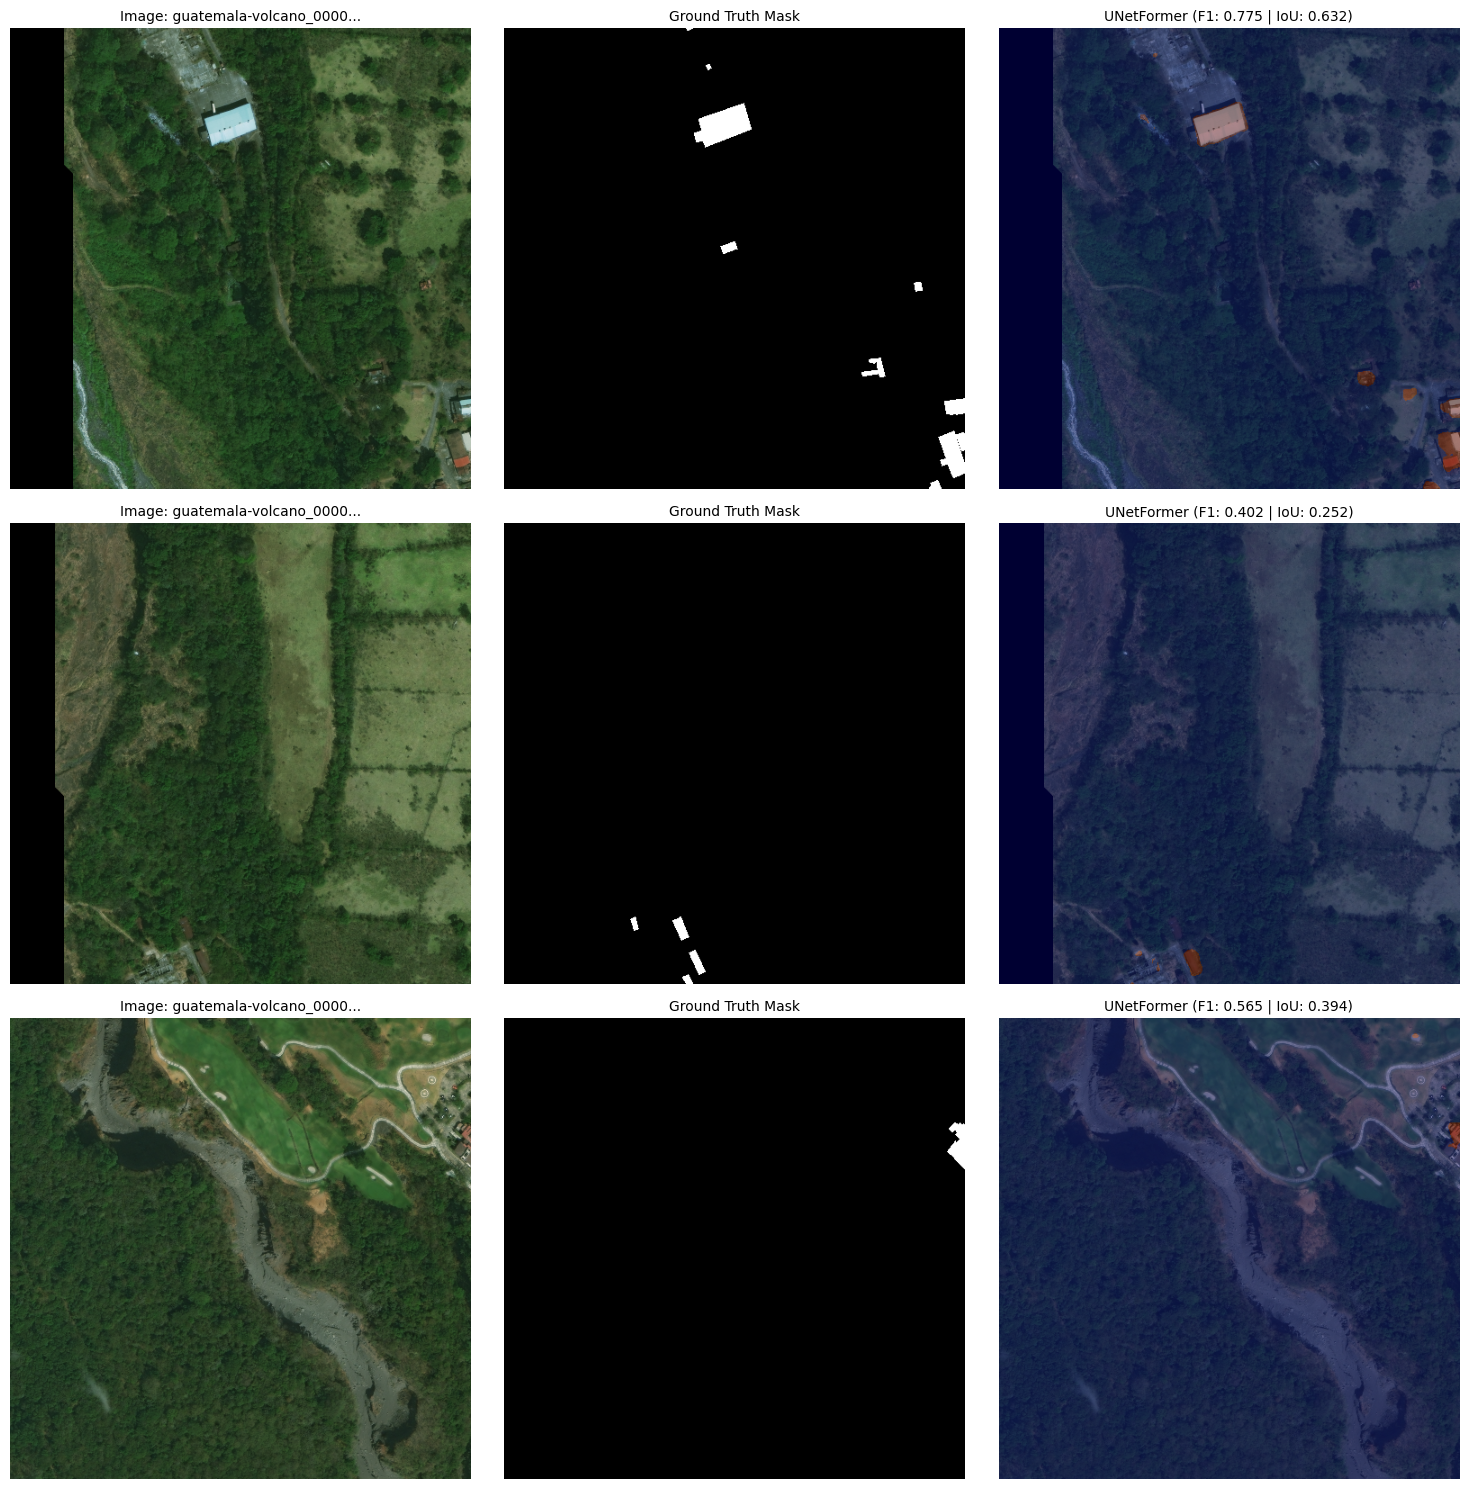

In [11]:
if __name__ == "__main__":
    # Initialize dataset & dataloader
    test_dataset = xBDPreDisasterMaskDataset(base_dir=DATASET_DIR, transform=test_transform)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
    
    # 1. INSTANTIATE THE MODEL FIRST 👈 (This was missing!)
    model = UNetFormer(num_classes=1).to(device)
    
    # 2. Load the checkpoint dictionary
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    
    # 3. Extract the model weights
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
        print(f" Loaded model_state_dict from checkpoint (Best IoU: {checkpoint.get('best_iou', 'N/A')})")
    else:
        state_dict = checkpoint
    
    # 4. Load state dict into UNetFormer
    model.load_state_dict(state_dict)
    model.eval()
    
    # Run evaluation & plot graphics
    vis_data = run_evaluation(model, test_loader)
    plot_test_results(vis_data)